In [1]:
"""
Classifying "Real-Life" images with a CNN
We'll use the CIFAR-10 dataset for images

Goals
Loading the CIFAR-10 DB
Preprocessing and Augmenting the data
Build our CNN
Train and Evaluate
Build a second CNN for improved
"""

import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, classification_report
from fastai.data.external import untar_data, URLs

SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [2]:
"""
Loading CIFAR-10

Yesterday we used the MNIST database for classifying digits
Recall, the data from yesterday was loaded directly from tensorflow
and had a shape of 28x28x1 (28x28 image with 1 color channel)

CIFAR-10 is an image database including 60,000 images spread across 10 classes
The images in CIFAR 10 are 32x32 and in full color so our final shape will be 32x32x3 for each image
Reminder we could pull this from tensorflow but it's sometimes slow
"""

# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", 'cat', 'deer', 'dog',
    'frog', 'horse', 'ship', 'truck'
]

print("Downloading data")
path = Path(untar_data(URLs.CIFAR))

train_dir = path / "train"
test_dir = path / "test"

print("Dataset Path:", path)
print("Train Path:", train_dir)
print("Test Path:", test_dir)

<div><progress max="168168549" value="168173568"></progress> 100.00% [168173568/168168549 00:03&lt;00:00]</div>

Dataset Path: /root/.fastai/data/cifar10
Train Path: /root/.fastai/data/cifar10/train
Test Path: /root/.fastai/data/cifar10/test


In [3]:
"""
This step is loading them into a Tensorflow dataset
If we loaded this from TF we could skip this step but sometimes you have to do this

Take our images directories and convert them
IMPORTANT:
- class-names to force the integer labels to match our expected order
- shuffle=False keeps the order to properly assign labels
- batch_size this allows us to grab all of the data at once basically

"""
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    color_mode='rgb',
    image_size=(32,32),
    batch_size=50000,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    color_mode='rgb',
    image_size=(32,32),
    batch_size=10000,
    shuffle=False
)

# Convert our DS to NumpyArrays
for images, labels in train_ds.take(1):
  X_train = images.numpy().astype("uint8") # 0-255
  y_train = labels.numpy().astype("int64")

for images, labels in test_ds.take(1):
  X_test = images.numpy().astype("uint8") # 0-255
  y_test = labels.numpy().astype("int64")


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


In [4]:
"""
Other things to look for when loading data from external sources
Sometimes the data is grouped by class
If I say validation_split=.1 inside the model.fit it'll just take the last 10%
and use it as the validation set

Let's take a look to see if the data is already shuffled
"""

print("First 20 labels:", y_train[:20]) # All airplane
print("Last 20 Labels:", y_train[-20:]) # All Truck

print("Class count in full training set")
for i, name in enumerate(class_names):
  print(f"{name}: {np.sum(y_train == i)}")

# Imagine we used the data as is
# The last 10% would be our validation set
print("Class count in last 10%")
last_10_percent = y_train[-5000:]
for i, name in enumerate(class_names):
  print(f"{name}: {np.sum(last_10_percent == i)}")

First 20 labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Last 20 Labels: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]
Class count in full training set
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000
Class count in last 10%
airplane: 0
automobile: 0
bird: 0
cat: 0
deer: 0
dog: 0
frog: 0
horse: 0
ship: 0
truck: 5000


In [5]:
# Split this data into train and test splits as we have done, specifically we
# will stratify the data to roughly spread it out

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=.1,
    random_state=SEED,
    stratify=y_train
)

print("Class count in training set")
for i, name in enumerate(class_names):
  print(f"{name}: {np.sum(y_train_model == i)}")

print("Class count in validation set")
for i, name in enumerate(class_names):
  print(f"{name}: {np.sum(y_val == i)}")

Class count in training set
airplane: 4500
automobile: 4500
bird: 4500
cat: 4500
deer: 4500
dog: 4500
frog: 4500
horse: 4500
ship: 4500
truck: 4500
Class count in validation set
airplane: 500
automobile: 500
bird: 500
cat: 500
deer: 500
dog: 500
frog: 500
horse: 500
ship: 500
truck: 500


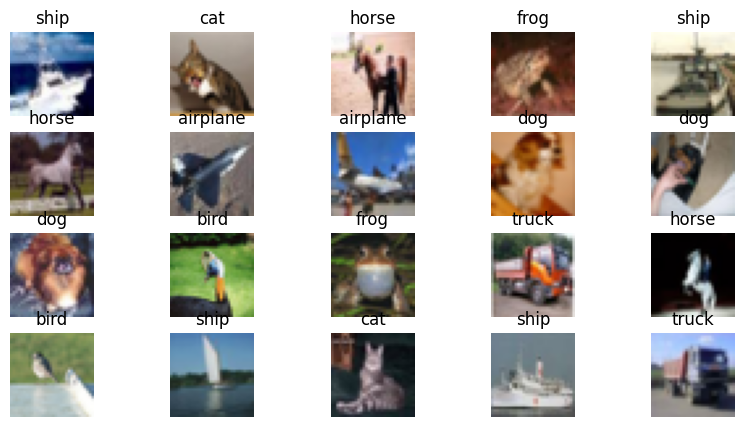

In [6]:
"""
Let's look at the data to get a feel
"""

plt.figure(figsize=(10,5))
random_indices = np.random.choice(len(X_train_model), size=20, replace=False)

for plot_position, idx in enumerate(random_indices, start=1):
  plt.subplot(4,5, plot_position)
  plt.imshow(X_train_model[idx])
  plt.title(class_names[y_train_model[idx]])
  plt.axis("off")

plt.show()

6
frog


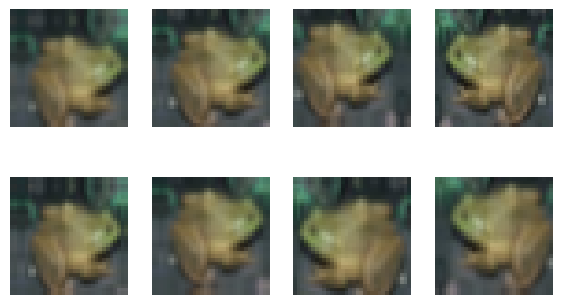

In [7]:
"""
Last step for preprocessing (I promise)

Data Augmentation
Data Augementation or modification allows us to artificially create more data
for our training model by augmenting the existing data

Common augments:
Rotate, slide, flip, zoom

"""
# We'll put this inside our model to train later
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(.08, .08),
    tf.keras.layers.RandomZoom(.08)
], name= "data_augmentation")

sample = X_train_model[1764]
label = y_train_model[1764]
print(label)
print(class_names[label])

plt.figure(figsize=(7,4))
for i in range(8):
  # The expand dims turns the shape from (32,32,3) -> (1,32,32,3)
  # Training = true because data augementation is a training tool, it only works
  # when training is set to true (training is true on model.fit())
  augmented = data_augmentation(tf.expand_dims(sample, axis = 0), training=True)
  plt.subplot(2,4, i+1)
  plt.imshow(tf.cast(augmented[0], tf.uint8))
  plt.axis("off")

plt.show()


In [8]:
"""
Helper functions to clear things up later
"""
def plot_history(history, title):
    # Plot training and validation accuracy/loss for one model.
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="training accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="training loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def evaluate_model(model, x_test, y_test, class_names, title):
    # Evaluate a trained model and return useful results.
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{title} test accuracy: {test_acc:.4f}")
    print(f"{title} test loss: {test_loss:.4f}")

    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    plt.title(f"{title} Confusion Matrix")
    plt.show()

    return {
        "title": title,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "y_pred": y_pred
    }


def show_mistakes(x_test, y_test, y_pred, class_names, title, max_images=24):
    # Show examples where the model prediction was wrong.
    mistakes = np.where(y_pred != y_test)[0]
    print(f"{title} mistakes:", len(mistakes))

    if len(mistakes) == 0:
        print("No mistakes to show.")
        return

    selected = mistakes[:max_images]

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(selected):
        plt.subplot(4, 6, i + 1)
        plt.imshow(x_test[idx])
        plt.title(f"T: {class_names[y_test[idx]]}\nP: {class_names[y_pred[idx]]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_comparison(histories, metric, title):
    # Compare one metric across multiple training histories.
    plt.figure(figsize=(8, 4))
    for name, history in histories.items():
        plt.plot(history.history[metric], label=name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [9]:
"""
Baseline CNN

Architecture
Input
Data Augmentation
Rescaling (Why rescale here?)
Convolution Layers
Max Pooling Layers
A Dense Layer (Fully Connected)
Dropout
Softmax output

Why are we rescaling in the model itself? It doesn't really matter too much
but if we can include some of our preprocessing in the model itself
we can use it on more generalized images
"""

baseline_model = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(32,32,3)),
    # Augment our data
    # Reminder this implicitly only happens during training
    data_augmentation,
    # Rescaling
    # We can use other scalers here but we know the values are between 0-255
    # so just divide by 255
    tf.keras.layers.Rescaling(1./255),


    # Convolution Blocks
    # Reminder, we add filters to our blocks as pattern learners
    # After learning a pattern we summarize using Pooling
    # Padding
    # Specifically Padding=same allows for the images to not be reduced in size
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"), # Learn basic patterns
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"), # Learn from the previous output
    tf.keras.layers.MaxPooling2D(), # Summarize the feature maps

    # A lot of this is trial and error
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"), # Learn basic patterns
    tf.keras.layers.MaxPooling2D(),


    # Finally we have a representation of the important features in the image
    # So we connect this to an MLP by flattening and then using a dense layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(.3),

    #Output
    tf.keras.layers.Dense(10, activation="softmax")
], name="baseline_cnn")

# Compile
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate= .001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Summarize
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,986 (1.54 MB)

 Trainable params: 402,986 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Let's train the model, we'll define the EarlyStopping callback to prevent overfitting
baseline_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max" # Checking for Maximized accuracy
    )
]

baseline_history = baseline_model.fit(
    X_train_model,
    y_train_model,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128, # How are the batches determined? Come back to this
    callbacks=baseline_callbacks
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3538 - loss: 1.7563 - val_accuracy: 0.5020 - val_loss: 1.3727
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5045 - loss: 1.3732 - val_accuracy: 0.5280 - val_loss: 1.2906
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5817 - loss: 1.1752 - val_accuracy: 0.6428 - val_loss: 1.0230
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6326 - loss: 1.0454 - val_accuracy: 0.6808 - val_loss: 0.9330
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6643 - loss: 0.9605 - val_accuracy: 0.7156 - val_loss: 0.8321
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6882 - loss: 0.8970 - val_accuracy: 0.7096 - val_loss: 0.8534
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7028 - loss: 0.8474 - val_accuracy: 0.7424 - val_loss: 0.7443
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7200 - loss: 0.8078 - val_acc

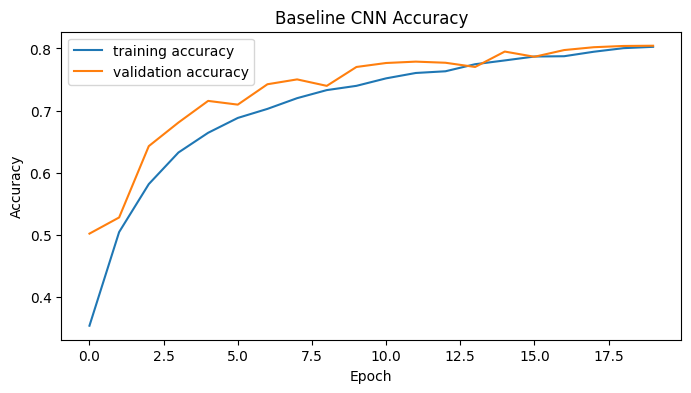

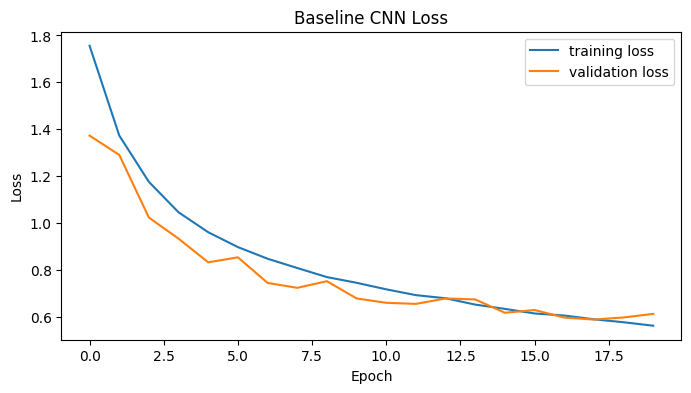

Baseline CNN test accuracy: 0.7986
Baseline CNN test loss: 0.6328

Classification Report:
              precision    recall  f1-score   support

    airplane       0.75      0.88      0.81      1000
  automobile       0.89      0.93      0.91      1000
        bird       0.79      0.65      0.72      1000
         cat       0.70      0.59      0.64      1000
        deer       0.81      0.73      0.76      1000
         dog       0.74      0.69      0.71      1000
        frog       0.83      0.86      0.84      1000
       horse       0.76      0.87      0.81      1000
        ship       0.90      0.87      0.89      1000
       truck       0.81      0.93      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



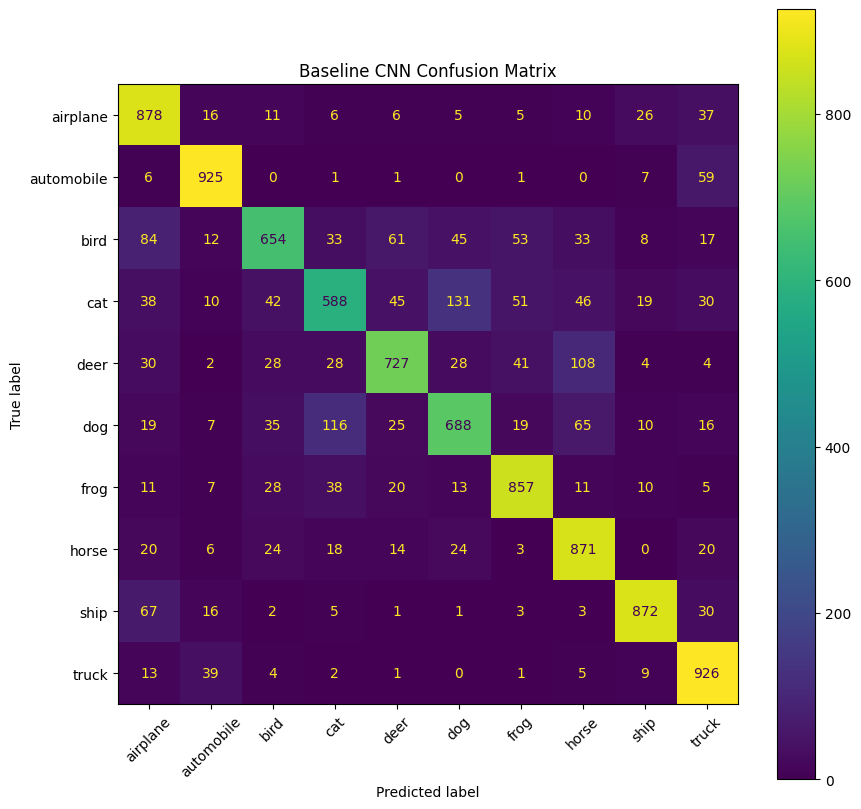

In [11]:
# Evaluate on our test data
# Uses the helper functions we defined earlier

plot_history(baseline_history, "Baseline CNN")

baseline_results = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    class_names,
    "Baseline CNN"
)

Baseline CNN Mistakes mistakes: 2014


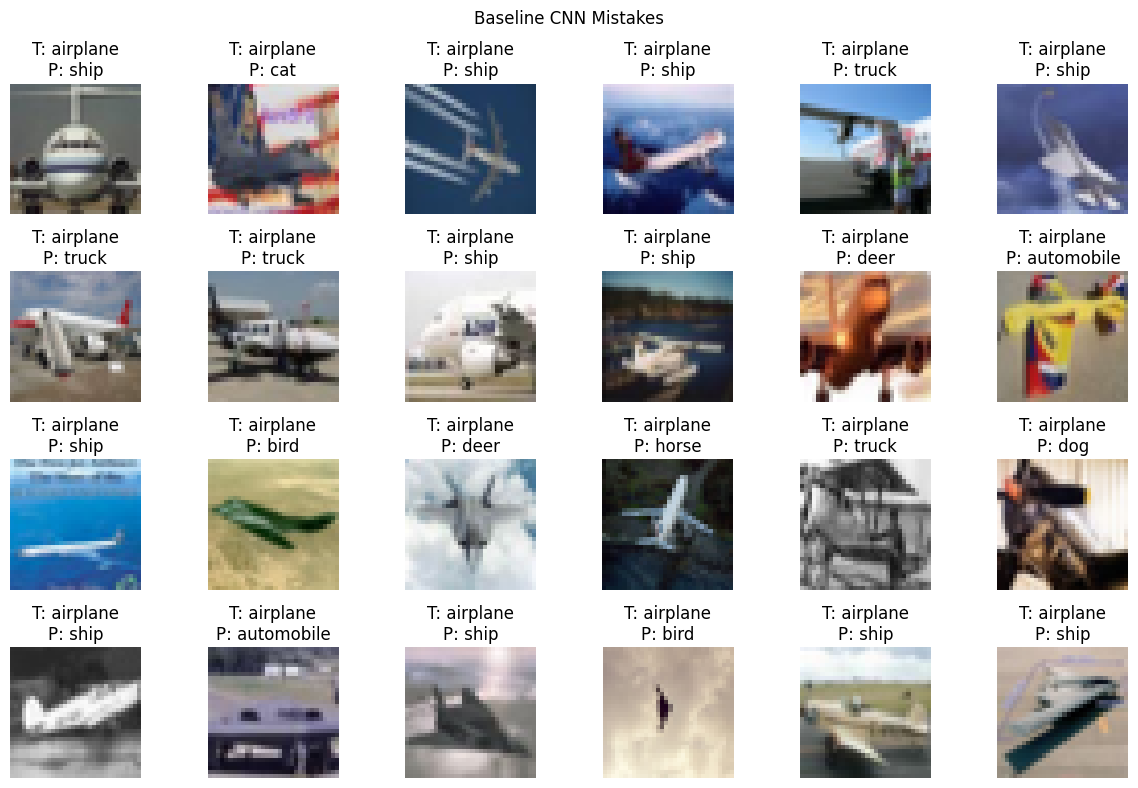

In [12]:
# Let's look at some mistakes to see some misclassifications
show_mistakes(
    X_test,
    y_test,
    baseline_results["y_pred"],
    class_names,
    "Baseline CNN Mistakes"
)

In [14]:
"""

At the point we've built a CNN that classifies images with ~80% accuracy, but we want to try
and pull out as much improvement as we can

- Batch Normalization
  - Batch Normalization is the process of scaling in the middle of a network
  - Rescaling previously was a preprocess step but the actual inputs can increase
  a lot during training so we'll add in BatchNormalization Layers after Conv2D
      - NOTE This removes the need for a bias in those layers
- Adding in More Dropout
- Large Dense Layer
- Larger Convolutional Layer
- Longer Training
- ReduceLROnPlateau
  - As we get closer to a theoretical perfect model, we want to slow down our
  learning rate to prevent overshooting the minimum
"""

improved_model = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(32,32,3)),
    # Augment our data
    # Reminder this implicitly only happens during training
    data_augmentation,
    # Rescaling
    # We can use other scalers here but we know the values are between 0-255
    # so just divide by 255
    tf.keras.layers.Rescaling(1./255),


    # Convolution Blocks
    tf.keras.layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(.2),

    tf.keras.layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(.3),

    # Adding in another convolution layer to make this more powerful
    tf.keras.layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(.3),

    #Output
    tf.keras.layers.Dense(10, activation="softmax")
], name="improved_cnn")

# Compile
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Summarize
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,234 (3.11 MB)

 Trainable params: 814,826 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [15]:
# Training time
improved_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max" # Checking for Maximized accuracy
    ),
    # Reduce learning rate on Plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=.5,
        patience=3,
        min_lr = 1e-5, #.00001
        verbose = 1
    )
]

improved_history = improved_model.fit(
    X_train_model,
    y_train_model,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128, # How are the batches determined? Come back to this
    callbacks=improved_callbacks
)

Epoch 1/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.4176 - loss: 1.6126 - val_accuracy: 0.2788 - val_loss: 2.2516 - learning_rate: 0.0010
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.5705 - loss: 1.1970 - val_accuracy: 0.5976 - val_loss: 1.1134 - learning_rate: 0.0010
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6436 - loss: 1.0028 - val_accuracy: 0.6982 - val_loss: 0.8397 - learning_rate: 0.0010
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6836 - loss: 0.8959 - val_accuracy: 0.6640 - val_loss: 0.9719 - learning_rate: 0.0010
Epoch 5/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7068 - loss: 0.8244 - val_accuracy: 0.7136 - val_loss: 0.8247 - learning_rate: 0.0010
Epoch 6/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7269 - loss: 0.7714 - val_accuracy: 0.6254 - val_loss: 1.3034 - learning_rate: 0.0010
Epoch 7/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.7444 - l

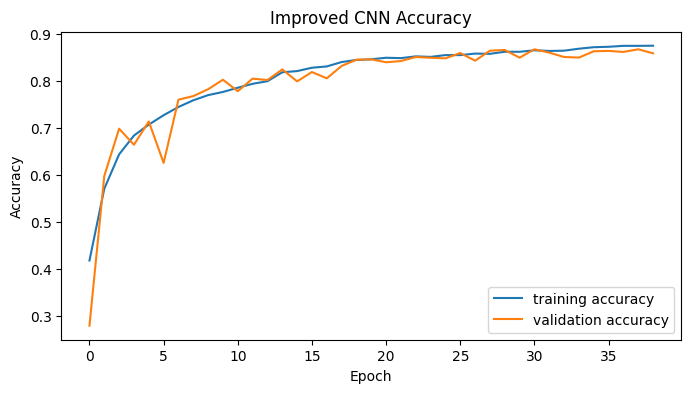

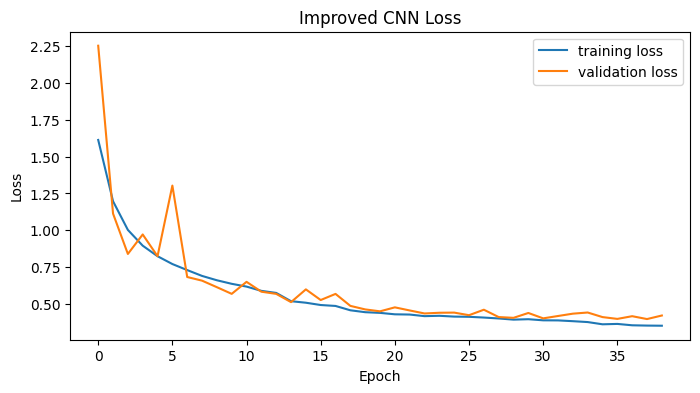

Improved CNN test accuracy: 0.8578
Improved CNN test loss: 0.4237

Classification Report:
              precision    recall  f1-score   support

    airplane       0.89      0.86      0.87      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.81      0.80      0.81      1000
         cat       0.76      0.69      0.72      1000
        deer       0.87      0.81      0.84      1000
         dog       0.85      0.75      0.80      1000
        frog       0.78      0.95      0.85      1000
       horse       0.91      0.90      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.87      0.95      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



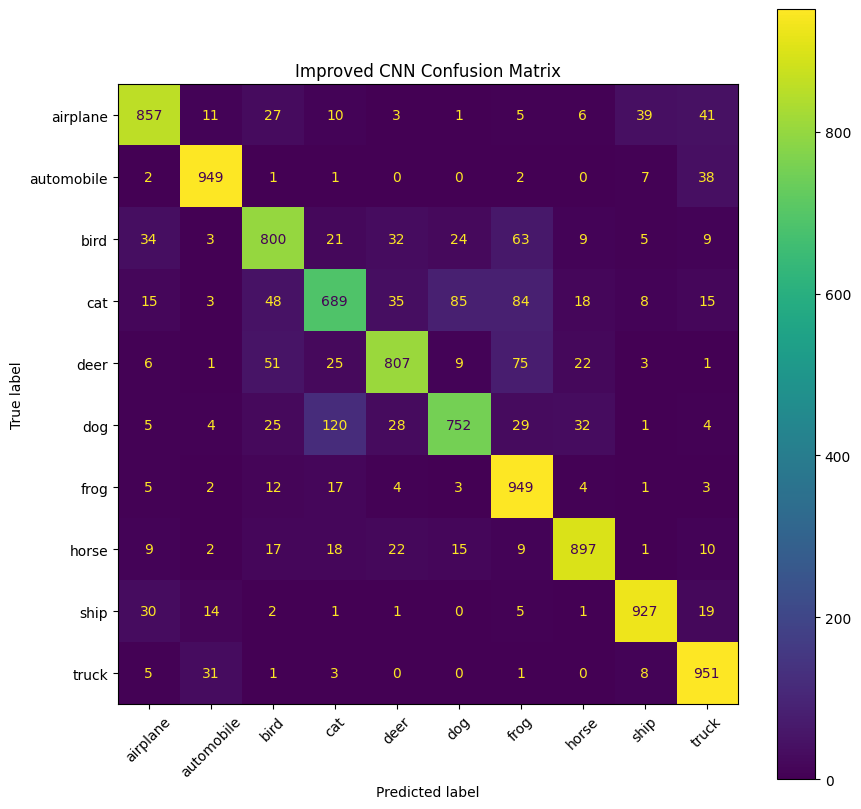

Improved CNN Mistakes mistakes: 1422


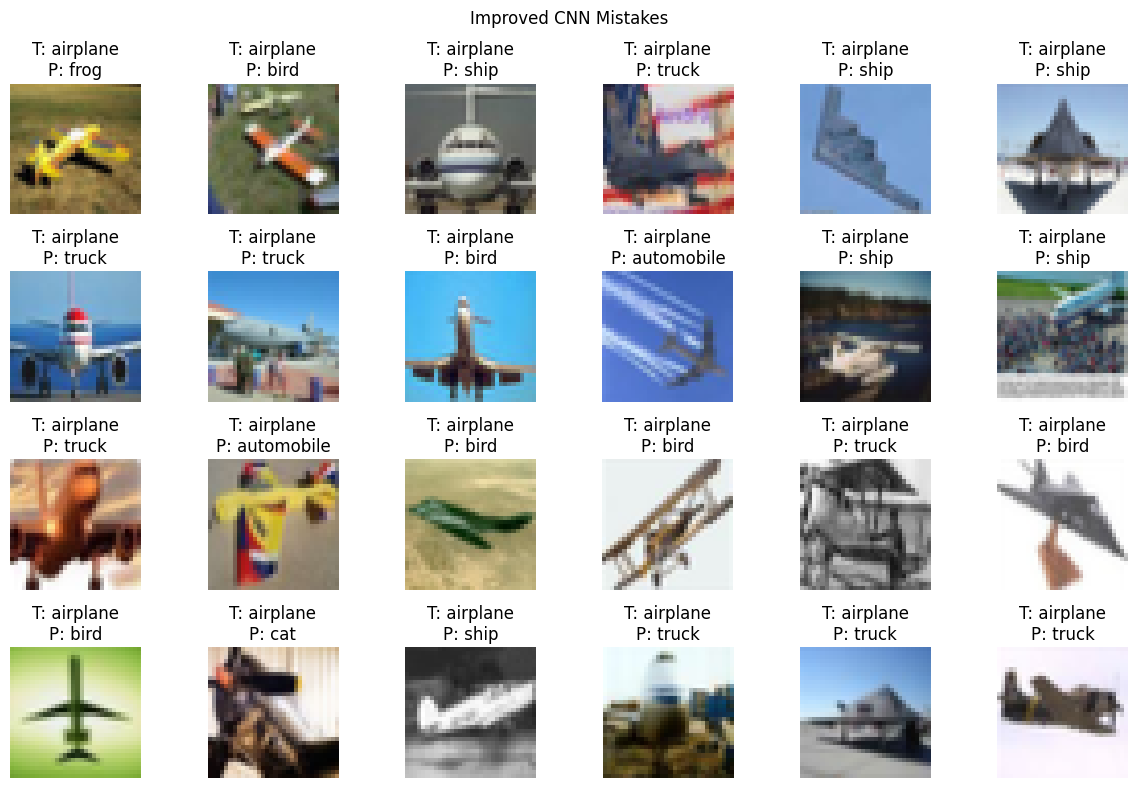

In [16]:
plot_history(improved_history, "Improved CNN")

improved_results = evaluate_model(
    improved_model,
    X_test,
    y_test,
    class_names,
    "Improved CNN"
)

show_mistakes(
    X_test,
    y_test,
    improved_results["y_pred"],
    class_names,
    "Improved CNN Mistakes"
)

In [17]:
# Let's compare our test accuracies
print("--- Test Set Comparison ---")
print(f"Baseline CNN accuracy: {baseline_results['test_accuracy']:.4f}")
print(f"Improved CNN accuracy: {improved_results['test_accuracy']:.4f}")
print(f"Accuracy change: {improved_results['test_accuracy'] - baseline_results['test_accuracy']:+.4f}")

print("\nBaseline CNN loss:", round(baseline_results["test_loss"], 4))
print("Improved CNN loss:", round(improved_results["test_loss"], 4))

--- Test Set Comparison ---
Baseline CNN accuracy: 0.7986
Improved CNN accuracy: 0.8578
Accuracy change: +0.0592

Baseline CNN loss: 0.6328
Improved CNN loss: 0.4237


Saving cash32.png to cash32 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted class: dog
Confidence: 50.98%

All class probabilities:
airplane    : 0.00%
automobile  : 0.01%
bird        : 1.12%
cat         : 41.58%
deer        : 0.83%
dog         : 50.98%
frog        : 3.56%
horse       : 1.89%
ship        : 0.00%
truck       : 0.03%


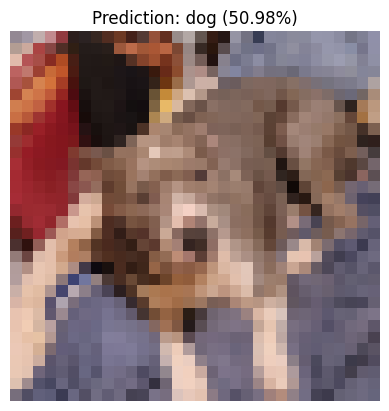

In [23]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

img = load_img(
    image_path,
    color_mode="rgb",
    target_size=(32, 32)
)

img_array = img_to_array(img).astype("uint8")
img_batch = np.expand_dims(img_array, axis=0)

predictions = improved_model.predict(img_batch)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index]

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

print("\nAll class probabilities:")
for class_name, probability in zip(class_names, predictions[0]):
    print(f"{class_name:12s}: {probability:.2%}")

plt.imshow(img_array)
plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
plt.axis("off")
plt.show()